In [17]:
import kagglehub

path = kagglehub.dataset_download("fanbyprinciple/iot-device-identification")

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
data_train = pd.read_csv(path + "/iot_device_train.csv")
data_test = pd.read_csv(path + "/iot_device_test.csv")

In [20]:
data_train.device_category.value_counts()

device_category
security_camera    100
TV                 100
smoke_detector     100
thermostat         100
water_sensor       100
watch              100
baby_monitor       100
motion_sensor      100
lights             100
socket             100
Name: count, dtype: int64

In [21]:
data_test.device_category.value_counts()

device_category
baby_monitor       100
lights             100
motion_sensor      100
security_camera    100
smoke_detector     100
socket             100
thermostat         100
TV                 100
watch              100
Name: count, dtype: int64

In [22]:
# Since we have 1 more category in the test set, we will merge the two datasets
data = pd.concat([data_train, data_test], axis=0, ignore_index=True)
data.shape

(1900, 298)

In [23]:
# Shuffle the dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,48,18,30,1382,654,0.898350,728,0,0,1.7060,...,0,0,0,0,0,0,0,0,1,motion_sensor
1,9,5,5,1213,743,1.142203,668,0,0,0.7328,...,0,0,0,1,0,0,0,0,0,TV
2,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
4,12,6,6,1548,645,0.714285,903,0,0,0.8530,...,0,0,0,0,0,0,0,0,1,security_camera


Text(0.5, 1.0, 'Total Missing Values')

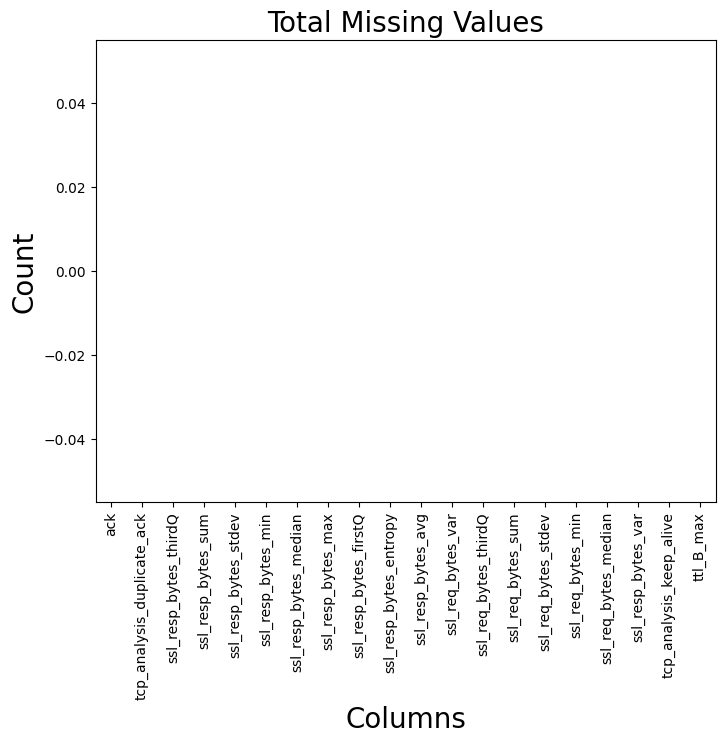

In [24]:
total = data.isnull().sum().sort_values(ascending=False)
total_select = total.head(20)
total_select.plot(kind="bar", figsize = (8,6), fontsize = 10)
plt.xlabel("Columns", fontsize = 20)
plt.ylabel("Count", fontsize = 20)
plt.title("Total Missing Values", fontsize = 20)


In [25]:
X = data.drop(columns=["device_category"])
y = data["device_category"]

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
y

array([3, 0, 8, ..., 2, 5, 2], shape=(1900,))

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_cloudfront.net,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved
0,-0.040308,-0.056176,-0.034229,-0.030082,-0.029049,-0.081472,-0.091368,0.0,-0.601293,-0.084339,...,0.0,0.0,-0.140927,0.0,-1.118564,-0.684336,0.0,0.0,0.0,4.649629
1,-0.049052,-0.067729,-0.041551,-0.030117,-0.029031,-0.011324,-0.092141,0.0,-0.601293,-0.084647,...,0.0,0.0,-0.140927,0.0,0.894004,-0.684336,0.0,0.0,0.0,-0.215071
2,-0.049052,-0.067729,-0.041551,-0.030117,-0.029031,0.179878,-0.092141,0.0,-0.601293,-0.084380,...,0.0,0.0,-0.140927,0.0,0.894004,-0.684336,0.0,0.0,0.0,-0.215071
3,-0.049052,-0.067729,-0.041551,-0.030117,-0.029031,0.179878,-0.092141,0.0,-0.601293,-0.084380,...,0.0,0.0,-0.140927,0.0,0.894004,-0.684336,0.0,0.0,0.0,-0.215071
4,-0.048380,-0.066840,-0.041258,-0.030049,-0.029051,-0.134422,-0.089115,0.0,-0.601293,-0.084609,...,0.0,0.0,-0.140927,0.0,-1.118564,-0.684336,0.0,0.0,0.0,4.649629


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled.to_numpy(), y, test_size=0.2, random_state=42)

In [29]:
from xgboost import XGBClassifier
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/Users/humbertoangelplataduran/Documents/6 Semester/BusinessDataScience/Proyect_2/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:35:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.93      0.87      0.90        31
           1       1.00      0.97      0.99        36
           2       0.61      0.68      0.64        34
           3       1.00      0.98      0.99        41
           4       0.98      1.00      0.99        43
           5       1.00      1.00      1.00        40
           6       0.62      0.58      0.60        36
           7       0.98      0.98      0.98        49
           8       0.94      0.98      0.96        48
           9       0.57      0.55      0.56        22

    accuracy                           0.88       380
   macro avg       0.86      0.86      0.86       380
weighted avg       0.89      0.88      0.88       380



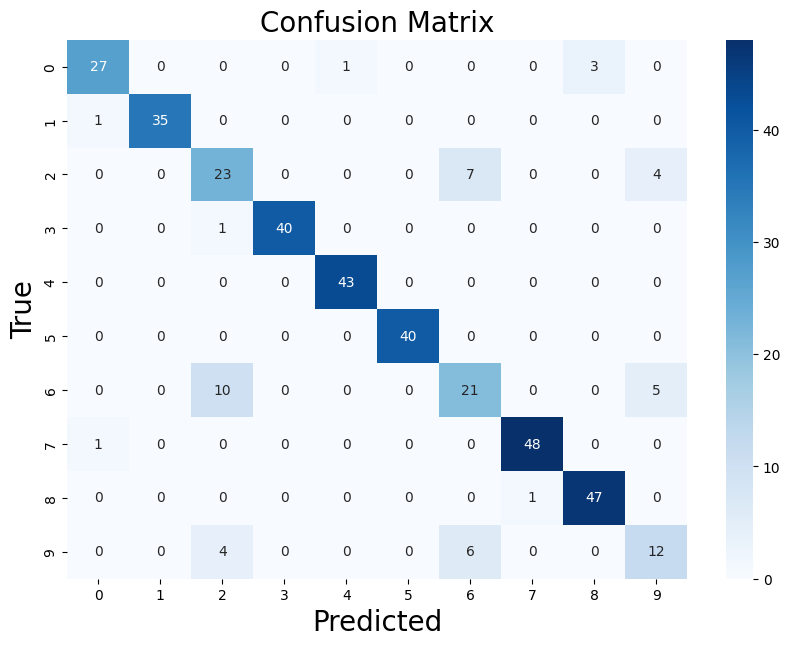

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=20)
plt.ylabel('True', fontsize=20)
plt.title('Confusion Matrix', fontsize=20)
plt.show()